### Cross-Country Solar Comparison: Benin, Togo, Sierra Leone
#### > **Objective**: Compare solar potential across three countries using cleaned datasets.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

In [5]:
benin = pd.read_csv('../data/benin_clean.csv', parse_dates=['Timestamp'])
togo = pd.read_csv('../data/togo_clean.csv', parse_dates=['Timestamp'])
sierraleone = pd.read_csv('../data/sierraleone-bumbuna_clean.csv', parse_dates=['Timestamp'])

In [6]:
# Add country column
benin['Country'] = 'Benin'
togo['Country'] = 'Togo'
sierraleone['Country'] = 'Sierra Leone'

In [7]:
# Combine
df = pd.concat([benin, togo, sierraleone], ignore_index=True)
print(f"Combined shape: {df.shape}")
df.head()

Combined shape: (1543517, 21)


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,...,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments,WD_rounded,Country
0,2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,...,122.1,0.0,998,0,0.0,26.3,26.2,NaN,120.0,Benin
1,2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,...,0.0,0.0,998,0,0.0,26.3,26.2,NaN,0.0,Benin
2,2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,...,124.6,1.5,997,0,0.0,26.4,26.2,NaN,120.0,Benin
3,2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,...,120.3,1.3,997,0,0.0,26.4,26.3,NaN,120.0,Benin
4,2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,...,113.2,1.0,997,0,0.0,26.4,26.3,NaN,110.0,Benin


### METRIC COMPARISON - BOXPLOTS

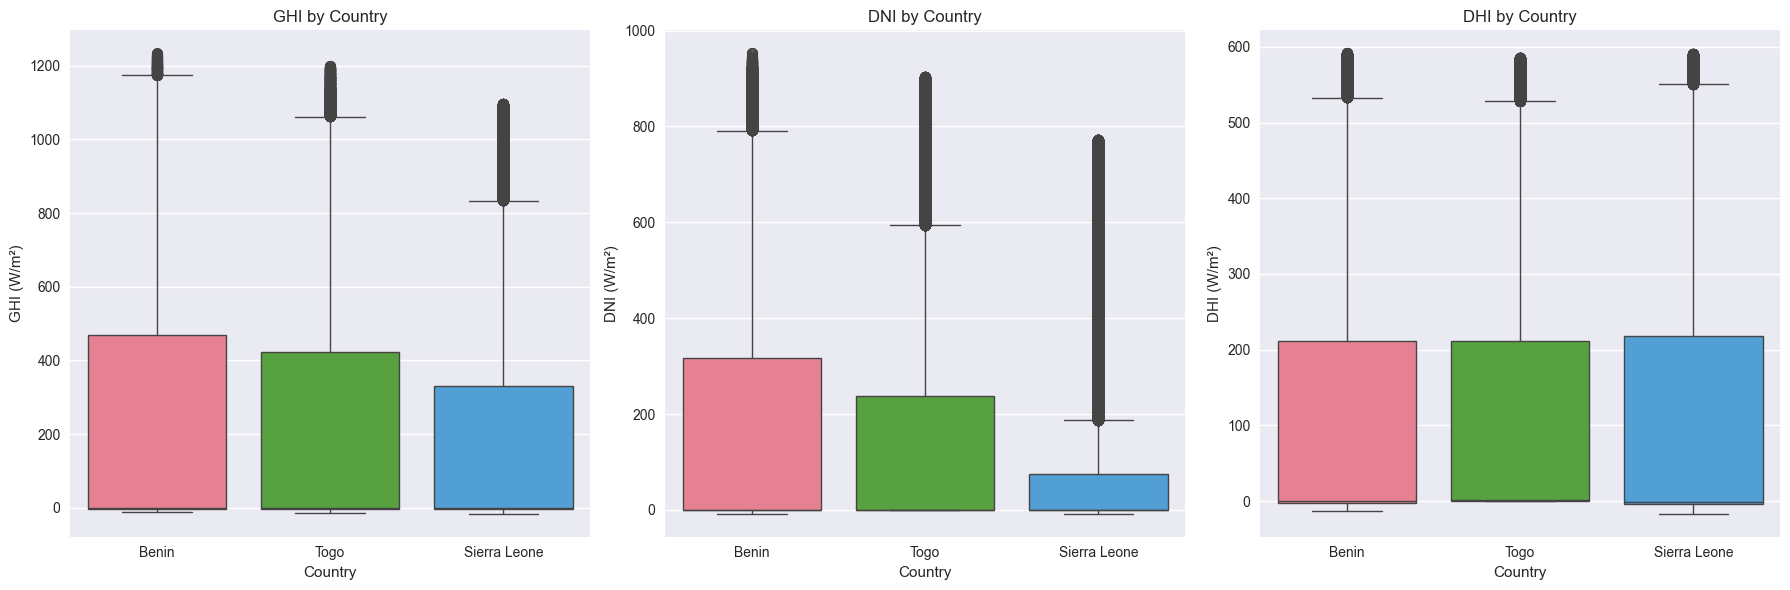

In [8]:
metrics = ['GHI', 'DNI', 'DHI']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, metric in enumerate(metrics):
    sns.boxplot(data=df, x='Country', y=metric, ax=axes[i], palette="husl")
    axes[i].set_title(f'{metric} by Country')
    axes[i].set_ylabel(f'{metric} (W/m²)')
plt.tight_layout()
plt.show()

### STATISTICAL TESTING - Kruskal-Wallis (non-parametric)

In [9]:
ghi_by_country = [group['GHI'].values for name, group in df.groupby('Country')]

kruskal_stat, p_value = stats.kruskal(*ghi_by_country)
print(f"Kruskal-Wallis Test on GHI:")
print(f"  H-statistic: {kruskal_stat:.2f}")
print(f"  p-value: {p_value:.2e}")

alpha = 0.05
if p_value < alpha:
    print("  → Significant differences in GHI across countries (p < 0.05)")
else:
    print("  → No significant differences (p ≥ 0.05)")

Kruskal-Wallis Test on GHI:
  H-statistic: 6548.53
  p-value: 0.00e+00
  → Significant differences in GHI across countries (p < 0.05)


### RANKING BY AVERAGE GHI

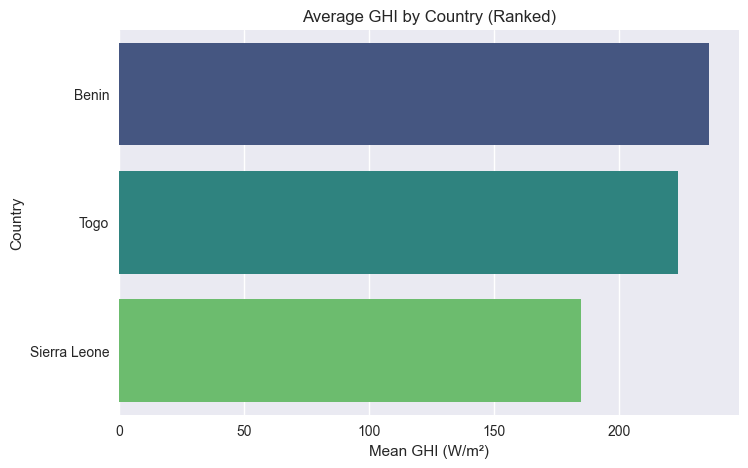

In [10]:
ghi_means = df.groupby('Country')['GHI'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=ghi_means.values, y=ghi_means.index, palette="viridis")
plt.title('Average GHI by Country (Ranked)')
plt.xlabel('Mean GHI (W/m²)')
plt.show()